In [2]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Pfad zur CSV-Datei
file_path = '../participant_package/reefer_release.csv'

# Lade die Daten in einen DataFrame
df_reefer = pd.read_csv(file_path, sep=';', decimal=',')

# Zeige die ersten paar Zeilen an
df_reefer.head(50)

,container_visit_uuid,customer_uuid,container_uuid,HardwareType,EventTime,AvPowerCons,TtlEnergyConsHour,TtlEnergyCons,TemperatureSetPoint,TemperatureAmbient,TemperatureReturn,RemperatureSupply,ContainerSize,stack_tier
0,e81b2358-de43-a16e-099e-4561b75d88ee,1b16f35f-77fc-3548-4bba-94630695e99e,22397407-6f6f-8118-a57e-7d29109182f2,DecosVa,2025-01-01 00:00:00.000,887.793488,887.437326,1.519376e+06,-18.0,9.625000,-18.100000,-19.950000,40.0,1.0
1,e81b2358-de43-a16e-099e-4561b75d88ee,1b16f35f-77fc-3548-4bba-94630695e99e,22397407-6f6f-8118-a57e-7d29109182f2,DecosVa,2025-01-01 01:00:00.000,928.909479,928.094827,1.520305e+06,-18.0,10.066667,-18.000000,-19.900000,40.0,1.0
2,e81b2358-de43-a16e-099e-4561b75d88ee,1b16f35f-77fc-3548-4bba-94630695e99e,22397407-6f6f-8118-a57e-7d29109182f2,DecosVa,2025-01-01 02:00:00.000,929.646456,929.299938,1.521234e+06,-18.0,10.250000,-17.975000,-19.850000,40.0,1.0
3,e81b2358-de43-a16e-099e-4561b75d88ee,1b16f35f-77fc-3548-4bba-94630695e99e,22397407-6f6f-8118-a57e-7d29109182f2,DecosVa,2025-01-01 03:00:00.000,923.307627,925.736719,1.522160e+06,-18.0,10.550000,-17.900000,-19.800000,40.0,1.0
4,e81b2358-de43-a16e-099e-4561b75d88ee,1b16f35f-77fc-3548-4bba-94630695e99e,22397407-6f6f-8118-a57e-7d29109182f2,DecosVa,2025-01-01 04:00:00.000,945.029192,944.842351,1.523104e+06,-18.0,11.066667,-17.833333,-19.766667,40.0,1.0
5,e81b2358-de43-a16e-099e-4561b75d88ee,1b16f35f-77fc-3548-4bba-94630695e99e,22397407-6f6f-8118-a57e-7d29109182f2,DecosVa,2025-01-01 05:00:00.000,948.925318,948.117326,1.524053e+06,-18.0,11.275000,-17.800000,-19.725000,40.0,1.0
6,e81b2358-de43-a16e-099e-4561b75d88ee,1b16f35f-77fc-3548-4bba-94630695e99e,22397407-6f6f-8118-a57e-7d29109182f2,DecosVa,2025-01-01 06:00:00.000,943.195856,942.197902,1.524995e+06,-18.0,11.266667,-17.800000,-19.666667,40.0,1.0
7,e81b2358-de43-a16e-099e-4561b75d88ee,1b16f35f-77fc-3548-4bba-94630695e99e,22397407-6f6f-8118-a57e-7d29109182f2,DecosVa,2025-01-01 07:00:00.000,461.699028,461.312800,1.525456e+06,-18.0,10.200000,-13.000000,-18.500000,40.0,1.0
8,e81b2358-de43-a16e-099e-4561b75d88ee,1b16f35f-77fc-3548-4bba-94630695e99e,22397407-6f6f-8118-a57e-7d29109182f2,DecosVa,2025-01-01 08:00:00.000,919.601632,919.536424,1.526376e+06,-18.0,11.533333,-17.566667,-18.933333,40.0,1.0
9,e81b2358-de43-a16e-099e-4561b75d88ee,1b16f35f-77fc-3548-4bba-94630695e99e,22397407-6f6f-8118-a57e-7d29109182f2,DecosVa,2025-01-01 09:00:00.000,916.454445,915.682541,1.527291e+06,-18.0,11.200000,-17.600000,-19.650000,40.0,1.0


In [4]:
# Design-Einstellungen für die Plots
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Erster Check
print(df_reefer.info())
print(df_reefer.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3774557 entries, 0 to 3774556
Data columns (total 14 columns):
 #   Column                Dtype  
---  ------                -----  
 0   container_visit_uuid  object 
 1   customer_uuid         object 
 2   container_uuid        object 
 3   HardwareType          object 
 4   EventTime             object 
 5   AvPowerCons           float64
 6   TtlEnergyConsHour     float64
 7   TtlEnergyCons         float64
 8   TemperatureSetPoint   float64
 9   TemperatureAmbient    float64
 10  TemperatureReturn     float64
 11  RemperatureSupply     float64
 12  ContainerSize         float64
 13  stack_tier            float64
dtypes: float64(9), object(5)
memory usage: 403.2+ MB
None
        AvPowerCons  TtlEnergyConsHour  TtlEnergyCons  TemperatureSetPoint  \
count  3.774557e+06       3.774557e+06   3.774557e+06         3.774557e+06   
mean   2.375015e+03       2.368592e+03   2.339036e+05        -7.746596e-02   
std    2.022693e+03       2.958553

In [5]:
# Alle Leerzeichen am Anfang/Ende der Spaltennamen entfernen
df_reefer.columns = [col.strip() for col in df_reefer.columns]

print("Gesäuberte Spalten:", df_reefer.columns.tolist())

Gesäuberte Spalten: ['container_visit_uuid', 'customer_uuid', 'container_uuid', 'HardwareType', 'EventTime', 'AvPowerCons', 'TtlEnergyConsHour', 'TtlEnergyCons', 'TemperatureSetPoint', 'TemperatureAmbient', 'TemperatureReturn', 'RemperatureSupply', 'ContainerSize', 'stack_tier']


In [6]:
# Den Tippfehler 'RemperatureSupply' -> 'TemperatureSupply' beheben
df_reefer = df_reefer.rename(columns={'RemperatureSupply': 'TemperatureSupply'})

# Jetzt sollte die Berechnung ohne KeyError durchlaufen:
df_reefer['TempDelta_Internal'] = df_reefer['TemperatureReturn'] - df_reefer['TemperatureSupply']

print("Berechnung erfolgreich!")

Berechnung erfolgreich!


In [7]:
print("Verfügbare Spalten im Datensatz:")
print(df_reefer.columns.tolist())

Verfügbare Spalten im Datensatz:
['container_visit_uuid', 'customer_uuid', 'container_uuid', 'HardwareType', 'EventTime', 'AvPowerCons', 'TtlEnergyConsHour', 'TtlEnergyCons', 'TemperatureSetPoint', 'TemperatureAmbient', 'TemperatureReturn', 'TemperatureSupply', 'ContainerSize', 'stack_tier', 'TempDelta_Internal']


In [8]:
# Sicherstellen, dass EventTime ein Datetime-Objekt ist
df_reefer['EventTime'] = pd.to_datetime(df_reefer['EventTime'])

# Basis-Statistiken für deine numerischen Features
print("--- Deskriptive Statistik ---")
print(df_reefer[['AvPowerCons', 'TemperatureAmbient', 'TemperatureSetPoint', 'stack_tier']].describe())

# Check auf fehlende Werte
print("\n--- Fehlende Werte ---")
print(df_reefer.isnull().sum())

--- Deskriptive Statistik ---
        AvPowerCons  TemperatureAmbient  TemperatureSetPoint    stack_tier
count  3.774557e+06        3.774557e+06         3.774557e+06  3.762086e+06
mean   2.375015e+03        1.290180e+01        -7.746596e-02  1.747369e+00
std    2.022693e+03        7.689530e+00         1.731454e+01  7.849424e-01
min    0.000000e+00       -6.990000e+01        -3.500000e+01  1.000000e+00
25%    9.726295e+02        7.050000e+00        -2.000000e+01  1.000000e+00
50%    1.570393e+03        1.310000e+01         4.000000e+00  2.000000e+00
75%    3.180768e+03        1.837500e+01         1.500000e+01  2.000000e+00
max    1.413273e+04        7.480000e+01         3.000000e+01  3.000000e+00

--- Fehlende Werte ---
container_visit_uuid        0
customer_uuid              11
container_uuid              0
HardwareType                0
EventTime                   0
AvPowerCons                 0
TtlEnergyConsHour           0
TtlEnergyCons               0
TemperatureSetPoint         0
T

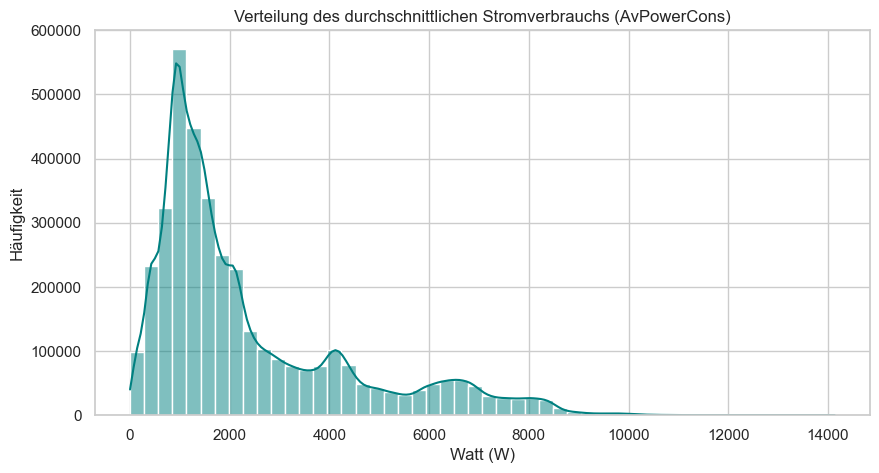

In [9]:
plt.figure(figsize=(10, 5))
sns.histplot(df_reefer['AvPowerCons'], bins=50, kde=True, color='teal')
plt.title('Verteilung des durchschnittlichen Stromverbrauchs (AvPowerCons)')
plt.xlabel('Watt (W)')
plt.ylabel('Häufigkeit')
plt.show()